<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/7.%20%20AI%20Modalities%20for%20Video/open_cv_demo.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print('OpenCV version:', cv2.__version__)


OpenCV version: 4.13.0


https://www.csfieldguide.org.nz/en/interactives/pixel-viewer/

R G B

BGR

In [2]:
# Helpers: OpenCV loads images as BGR, but matplotlib expects RGB.
def show(img, title='', cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_grid(images, titles=None, cols=3, figsize=(12, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

color shape: (564, 564, 3) dtype: uint8
gray  shape: (564, 564) dtype: uint8
working shape: (480, 480, 3)


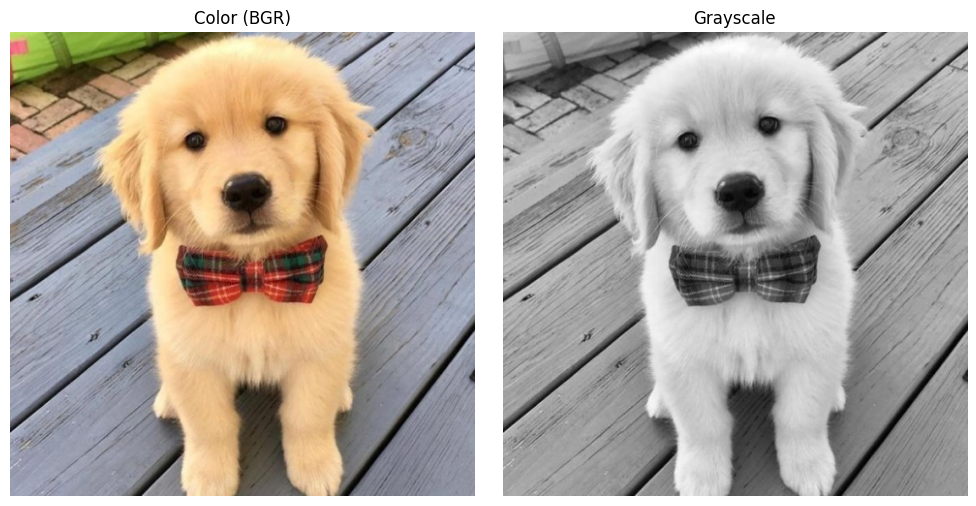

In [7]:
# Path to fluffy.jpeg (notebook lives in April 2026/, image lives in ref/)
IMG_PATH = Path('fluffy.jpeg').resolve()
assert IMG_PATH.exists(), f'Could not find {IMG_PATH}'

# Read in color (BGR) and grayscale
img      = cv2.imread(str(IMG_PATH))                          # shape (H, W, 3), BGR
img_gray = cv2.imread(str(IMG_PATH), cv2.IMREAD_GRAYSCALE)    # shape (H, W)

print('color shape:', img.shape,      'dtype:', img.dtype)
print('gray  shape:', img_gray.shape, 'dtype:', img_gray.dtype)


# Downscale once for the rest of the demo — keeps figures snappy
MAX_W = 480
scale = MAX_W / img.shape[1] if img.shape[1] > MAX_W else 1.0
img      = cv2.resize(img,      None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
img_gray = cv2.resize(img_gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
print('working shape:', img.shape)

# Save out a copy to demo imwrite
cv2.imwrite('fluffy_copy.png', img)

show_grid([img, img_gray], titles=['Color (BGR)', 'Grayscale'], cols=2, figsize=(10, 5))

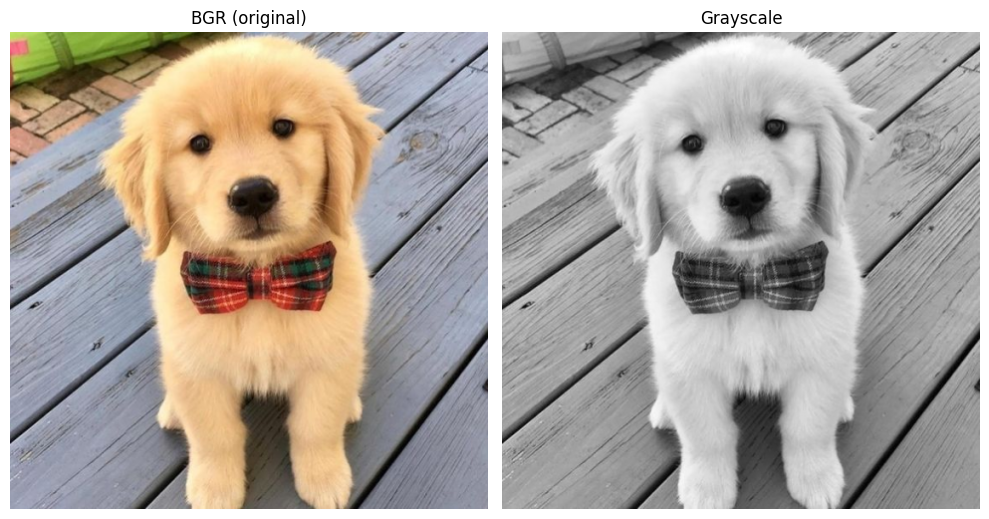

In [8]:
rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


show_grid([img, gray],
          titles=['BGR (original)', 'Grayscale'],
          cols=2, figsize=(10, 8))

In [9]:
cv2.imwrite('fluffy_copy_gray.png', gray)

True

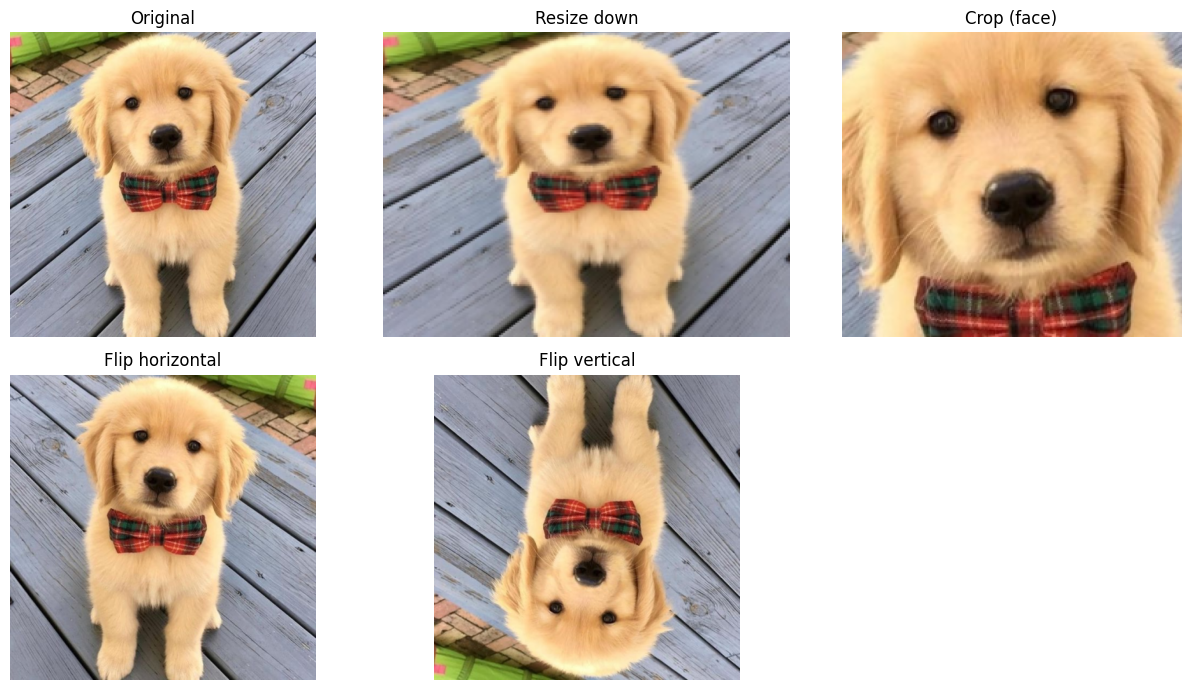

In [10]:
# Resize: cv2.resize(src, (new_w, new_h), interpolation=...)
# Common interpolations: INTER_NEAREST, INTER_LINEAR (default), INTER_CUBIC, INTER_AREA (best for shrinking)
resized_down = cv2.resize(img, (200, 150), interpolation=cv2.INTER_AREA)
resized_up   = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

# Crop with NumPy slicing — img[y1:y2, x1:x2]. Roughly the puppy's face.
h, w = img.shape[:2]
face_crop = img[int(h*0.10):int(h*0.55), int(w*0.25):int(w*0.75)]

# Flip: 0=vertical, 1=horizontal, -1=both
flipped_h = cv2.flip(img, 1)
flipped_v = cv2.flip(img, 0)

show_grid([img, resized_down, face_crop, flipped_h, flipped_v],
          titles=['Original', 'Resize down', 'Crop (face)', 'Flip horizontal', 'Flip vertical'],
          cols=3, figsize=(13, 7))

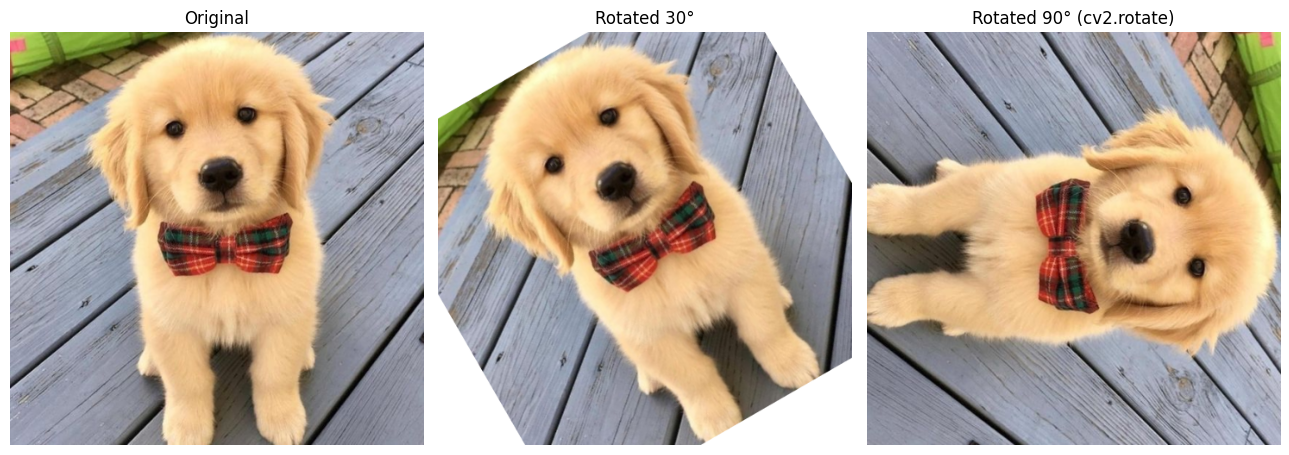

In [11]:
# Rotation by an arbitrary angle via affine matrix
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle=30, scale=1.0)
rotated = cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))

# Quick 90-degree rotation
rot90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

show_grid([img, rotated, rot90],
          titles=['Original', 'Rotated 30°', 'Rotated 90° (cv2.rotate)'],
          cols=3, figsize=(13, 5))